# Netflix is known for its work in data science, AI, and ML, particularly for building strong recommendation models and algorithms that understand customer behavior and patterns. Suppose you are working in a data-driven job role, and you have a dataset of more than 9,000 movies. You need to solve the following questions to help the company make informed business decisions accordingly.

- What is the most frequent genre of movies released on Netflix?
- Which has highest votes in vote avg column?
- What movie got the highest popularity? what's its genre?
- What movie got the lowest popularity? what's its genre?
- Which year has the most filmmed movies?


In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [169]:
df = pd.read_csv(r"F:\python\project 3\dataset\mymoviedb.csv")

In [170]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,12/15/2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,3/1/2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2/25/2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,11/24/2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,12/22/2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


There are inconsistencies in count so there has to be some missing data

In [172]:
df.duplicated().sum()

np.int64(0)

In [173]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

So there are 9 columns missing in title and so on for other columns.

In [174]:
missing_titles = df[df['Title'].isnull()]
print(missing_titles)

                   Release_Date Title Overview  Popularity Vote_Count  \
1106            - Just Desserts   NaN      NaN         NaN        NaN   
1107          - If The Hue Fits   NaN      NaN         NaN        NaN   
1108                  - Dust Up   NaN      NaN         NaN        NaN   
1109   - Scents And Sensibility   NaN      NaN         NaN        NaN   
1110    - Just One Of The Girls   NaN      NaN         NaN        NaN   
1111                - Volleybug   NaN      NaN         NaN        NaN   
1112            - Hide And Tink   NaN      NaN         NaN        NaN   
1113           - Rainbow's Ends   NaN      NaN         NaN        NaN   
1114           - Fawn And Games   NaN      NaN         NaN        NaN   

     Vote_Average Original_Language Genre Poster_Url  
1106          NaN               NaN   NaN        NaN  
1107          NaN               NaN   NaN        NaN  
1108          NaN               NaN   NaN        NaN  
1109          NaN               NaN   NaN        

these movies have all the other columns missing so removing these columns

In [175]:
df = df.dropna(subset=['Title'])

In [176]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           1
Vote_Count           1
Vote_Average         1
Original_Language    1
Genre                2
Poster_Url           2
dtype: int64

since i am not doing analysis on poster_url so missing there doesnt matter same goes for original language so i want to see what other columns are missing 

In [177]:
# Count missing values per row
row_missing_counts = df.isnull().sum(axis=1)

# Select rows with more than 3 missing values (you can adjust the threshold)
many_missing = df[row_missing_counts > 3]

# Display them
print(many_missing)


     Release_Date                  Title  \
1105   10/20/2013  Pixie Hollow Bake Off   

                                               Overview  Popularity  \
1105  Tink challenges Gelata to see who can bake the...         NaN   

     Vote_Count Vote_Average Original_Language Genre Poster_Url  
1105        NaN          NaN               NaN   NaN        NaN  


The two entries have more than 3 columns missing so remving them

In [178]:
# Drop the specific rows with many missing values
df = df.drop(index=[1105, 1115])
print(df.isnull().sum())   # should now show fewer missing values
print(df.shape)            # new row count after dropping


Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64
(9826, 9)


In [179]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9826 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9826 non-null   object 
 1   Title              9826 non-null   object 
 2   Overview           9826 non-null   object 
 3   Popularity         9826 non-null   float64
 4   Vote_Count         9826 non-null   object 
 5   Vote_Average       9826 non-null   object 
 6   Original_Language  9826 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 767.7+ KB


In [181]:
df.describe()

,Popularity
count,9826.000000
mean,40.323951
std,108.879332
min,13.354000
25%,16.128250
50%,21.195000
75%,35.179250
max,5083.954000


# Exploratory Summary
- We had dataframe consisting of 9837 rows and 9 columns
- 9 rows had all the info missing and one row had most of the data missing
- The missing data row was discarded as we had large dataset
- The date column was type converted same done with vote_count,vote_average
- Genre column has comm seperated values with white spaces that maybe needed to removed lateron

In [182]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'])
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'])

In [183]:
print(df['Release_Date'].dtypes)

datetime64[ns]


i dont need other values in date than year 

In [184]:
df['Release_Date']=df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('int32')

In [185]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


Dropping unnecessary column

In [186]:
columns= ['Overview','Original_Language','Poster_Url']

In [187]:
df.drop(columns,axis=1,inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [188]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


I want to categorize the vote 

In [189]:
def categorize_column(df,col,labels):
    edges = [df[col].describe()['min'],df[col].describe()['25%'],df[col].describe()['50%'],df[col].describe()['75%'],df[col].describe()['max']]
    df[col]=pd.cut(df[col],edges,labels=labels,duplicates='drop')
    return df

In [190]:
labels=["Not_popular","below_average","average","popular"]

In [191]:
categorize_column(df,'Vote_Average',labels)

df['Vote_Average'].unique()

['popular', 'below_average', 'average', 'Not_popular', NaN]
Categories (4, object): ['Not_popular' < 'below_average' < 'average' < 'popular']

In [192]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_average,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [193]:
df['Vote_Average'].value_counts()

Vote_Average
Not_popular      2467
popular          2450
average          2411
below_average    2398
Name: count, dtype: int64

Splitting the genre into lists and then explore our dataframe to have only one genre per row for each movie

In [194]:
df['Genre']=df['Genre'].str.split(', ')
df=df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


Casting column into category

In [195]:
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25792 entries, 0 to 25791
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25792 non-null  int32   
 1   Title         25792 non-null  object  
 2   Popularity    25792 non-null  float64 
 3   Vote_Count    25792 non-null  int64   
 4   Vote_Average  25551 non-null  category
 5   Genre         25792 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 756.6+ KB


In [197]:
df.nunique()

Release_Date     102
Title           9512
Popularity      8159
Vote_Count      3266
Vote_Average       4
Genre             19
dtype: int64

# Data Visualization

In [198]:
sns.set_style('whitegrid')

# What is the most frequent Genre of movies released on netflix?

In [199]:
df['Genre'].describe()

count     25792
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

Text(0.5, 1.0, 'Frequency distribution of Genre movies')

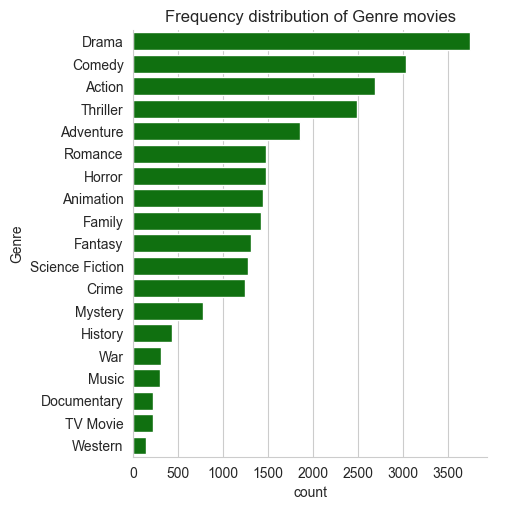

In [205]:
sns.catplot(y='Genre',data=df,kind = 'count',order=df['Genre'].value_counts().index,color='green')
plt.title("Frequency distribution of Genre movies")

# Which has highest votes in voteaverage column?

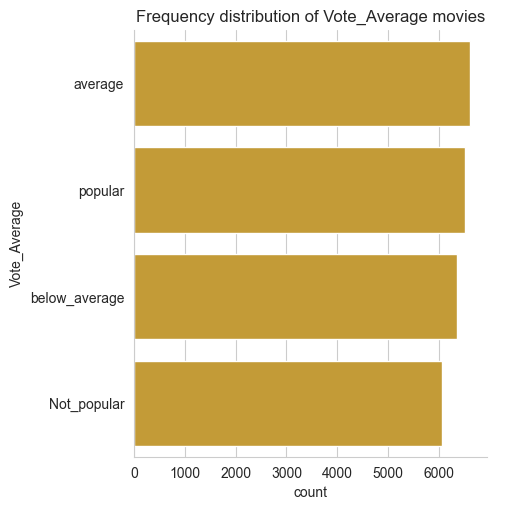

In [207]:
sns.catplot(y='Vote_Average',data=df,kind = 'count',order=df['Vote_Average'].value_counts().index,color='goldenrod')
plt.title("Frequency distribution of Vote_Average movies")
plt.show()

# What movie got the highest popularity and what genre is it?

In [208]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


# What movie got the lowest popularity and its genre?

In [209]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25786,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25787,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152,average,History
25789,1984,Threads,13.354,186,popular,War
25790,1984,Threads,13.354,186,popular,Drama
25791,1984,Threads,13.354,186,popular,Science Fiction


# Which Year has the most filmed movies?

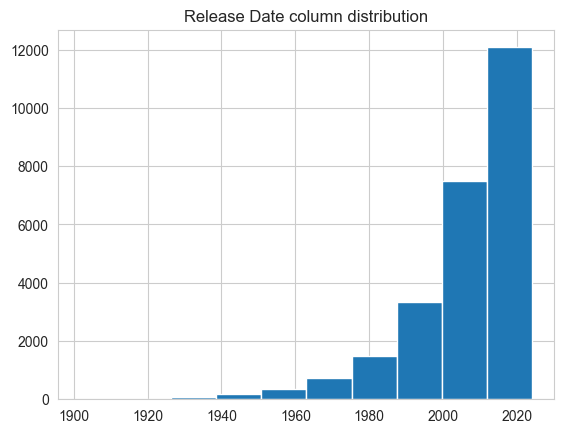

In [210]:
df['Release_Date'].hist()
plt.title("Release Date column distribution")
plt.show()